In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('./data/cleaned_disease_data.csv')
df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Alcohol',
       'Hepatitis_B', 'BMI', 'Polio', 'Diphtheria', 'HIV_AIDS', 'GDP',
       'thinness _1_19_years', 'thinness_5_9_years', 'Iso_code', 'Region',
       'Region_encoded', 'Schooling', 'Measles'],
      dtype='object')

In [3]:
X = df.drop(['Life_expectancy', 'Year', 'Iso_code', 'Region', 'Country','HIV_AIDS'], axis =1)
y = df['Life_expectancy']

In [4]:
X.head()

,Status,Alcohol,Hepatitis_B,BMI,Polio,Diphtheria,GDP,thinness _1_19_years,thinness_5_9_years,Region_encoded,Schooling,Measles
0,0,0.01,62.0,12.2,24.0,24.0,114.560000,2.3,2.5,1,1.264052,27.0
1,0,0.01,63.0,12.6,35.0,33.0,117.496980,2.1,2.4,1,1.315551,37.0
2,0,0.01,64.0,13.0,36.0,36.0,187.845950,19.9,2.2,1,1.367049,35.0
3,0,0.01,65.0,13.4,41.0,41.0,198.728544,19.7,19.9,1,1.418548,39.0
4,0,0.02,95.0,13.8,95.0,95.0,219.141353,19.5,19.7,1,1.470046,48.0


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_reg = RandomForestRegressor(max_depth=7, random_state=0)
rf_reg.fit(X_train,y_train)
rf_reg.score(X_train,y_train), rf_reg.score(X_test,y_test)

(0.9203970859936356, 0.8811742502029519)

In [7]:
y_pred = rf_reg.predict(X_test)

rf_reg_acc = r2_score(y_test, y_pred)
print(rf_reg_acc)

0.8811742502029519


In [8]:
# 5. 특성 중요도 시각화
rf_reg.feature_importances_

feat_impt_ser = pd.Series(
    rf_reg.feature_importances_, index=X.columns
).sort_values(ascending=False)
print(feat_impt_ser)

Region_encoded          0.562229
Schooling               0.088740
Measles                 0.057681
GDP                     0.049081
Status                  0.047409
thinness_5_9_years      0.039375
BMI                     0.038327
Polio                   0.028037
Alcohol                 0.027865
Hepatitis_B             0.027164
thinness _1_19_years    0.018392
Diphtheria              0.015702
dtype: float64


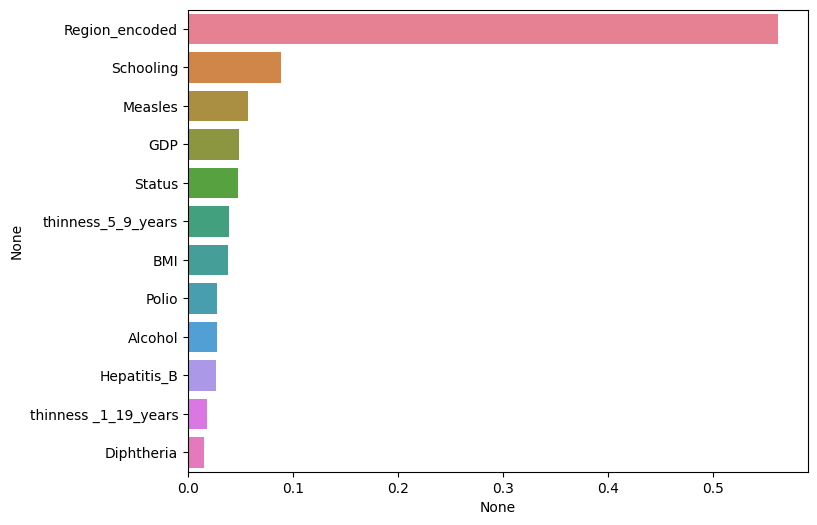

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x= feat_impt_ser,
    y = feat_impt_ser.index,
    hue = feat_impt_ser.index
)
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': range(95, 105),
    'max_depth': range(8 , 12),
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', None]
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')


In [11]:
grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(8, 12), 'max_features': ['sqrt', None], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [12]:
grid_search.best_params_

{'max_depth': 11,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 99}

In [13]:
grid_search.best_score_

np.float64(-8.356254991711854)

In [14]:
param_grid_v2 = {
    'max_depth': [11, 15, 20, None],
    'n_estimators': [ 200, 300, 500],
    'max_features': [None, 'sqrt'], # 이미 None이 좋다고 나왔으니 고정하거나 'sqrt' 정도만 추가
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [15]:
grid_search_v2 = GridSearchCV(RandomForestRegressor(), param_grid_v2, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

In [16]:
grid_search_v2.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [11, 15, ...], 'max_features': [None, 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [17]:
grid_search_v2.best_params_

{'max_depth': None,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 500}

In [18]:
grid_search_v2.best_score_

np.float64(-7.755950571506051)

In [19]:
gs_optimized_rf_reg= grid_search_v2.best_estimator_

In [20]:
gs_optimized_rf_reg.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [21]:
gs_optimized_rf_reg.score(X_train,y_train), gs_optimized_rf_reg.score(X_test,y_test)

(0.9886016087464164, 0.9214198574672653)

In [22]:
# 5. 특성 중요도 시각화
gs_optimized_rf_reg.feature_importances_

feat_impt_ser = pd.Series(
    gs_optimized_rf_reg.feature_importances_, index=X.columns
).sort_values(ascending=False)
print(feat_impt_ser)

Region_encoded          0.513843
Schooling               0.095275
Measles                 0.056545
GDP                     0.052048
BMI                     0.051567
thinness_5_9_years      0.044408
Status                  0.043936
Alcohol                 0.037687
Polio                   0.030899
Hepatitis_B             0.027367
thinness _1_19_years    0.025835
Diphtheria              0.020591
dtype: float64


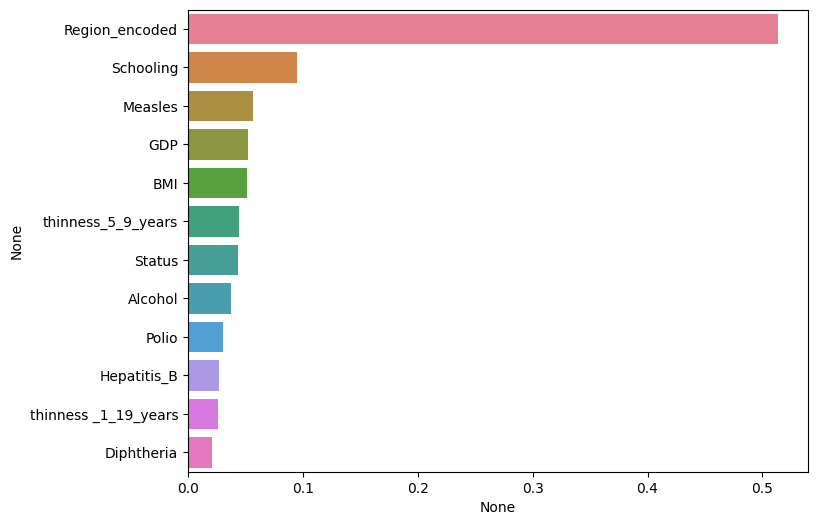

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x= feat_impt_ser,
    y = feat_impt_ser.index,
    hue = feat_impt_ser.index
)
plt.show()

### Optuna

In [24]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # 1. 탐색할 파라미터 범위 정의 (Grid보다 훨씬 넓게 설정 가능!)
    param = {
        # n_estimators: 100 근처에서 더 넓게 탐색
        'n_estimators': trial.suggest_int('n_estimators', 50, 500), 
        
        # max_depth: 8~20까지 확장 (아까 20이 나왔었으므로)
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        
        # 정수형 파라미터들
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        
        # 범주형 파라미터
        'max_features': trial.suggest_categorical('max_features', ['sqrt', None])
    }

    # 2. 모델 설정
    model = RandomForestRegressor(**param, n_jobs=-1, random_state=42)
    
    # 3. 교차 검증 (CV) - MSE를 평가지표로 사용
    # neg_mean_squared_error를 사용하므로 score가 클수록(0에 가까울수록) 좋은 것임
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    
    return score

# 4. 학습 최적화 실행
study = optuna.create_study(direction='maximize') # 점수가 커지는 방향으로
study.optimize(objective, n_trials=50) # 50번의 똑똑한 시도

# 5. 결과 출력
print(f"최적의 MSE 점수: {-study.best_value}") # 마이너스 떼고 출력
print(f"최적의 파라미터: {study.best_params}")

[I 2026-02-10 01:30:03,506] A new study created in memory with name: no-name-566cd0aa-06b3-4e8c-b708-1808d8a0e2ce
[I 2026-02-10 01:30:04,533] Trial 0 finished with value: -8.768479802363881 and parameters: {'n_estimators': 88, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: -8.768479802363881.
[I 2026-02-10 01:30:06,624] Trial 1 finished with value: -11.967764910647286 and parameters: {'n_estimators': 209, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: -8.768479802363881.
[I 2026-02-10 01:30:09,643] Trial 2 finished with value: -8.949182976206819 and parameters: {'n_estimators': 307, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: -8.768479802363881.
[I 2026-02-10 01:30:12,459] Trial 3 finished with value: -9.95291506611502 and parameters: {'n_estimators': 291, 'max_depth': 13, 'min_s

최적의 MSE 점수: 7.882724453113083
최적의 파라미터: {'n_estimators': 170, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}


In [25]:
# 1. Optuna가 찾은 최적 파라미터로 모델 생성
best_params = study.best_params
final_model = RandomForestRegressor(**best_params, random_state=42)

# 2. 전체 학습 데이터로 최종 학습
final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",170
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [26]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = final_model.predict(X_test)

# 성능 지표 계산
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"최종 R2 Score: {r2:.4f}")
print(f"최종 RMSE: {rmse:.4f}")

최종 R2 Score: 0.9216
최종 RMSE: 2.5899


In [27]:
final_model.feature_importances_

feat_impt_ser = pd.Series(
    final_model.feature_importances_, index=X.columns
).sort_values(ascending=False)
print(feat_impt_ser)

Region_encoded          0.516045
Schooling               0.092649
Measles                 0.056400
GDP                     0.052420
BMI                     0.050687
Status                  0.044989
thinness_5_9_years      0.044600
Alcohol                 0.036908
Polio                   0.031981
thinness _1_19_years    0.025980
Hepatitis_B             0.023683
Diphtheria              0.023658
dtype: float64


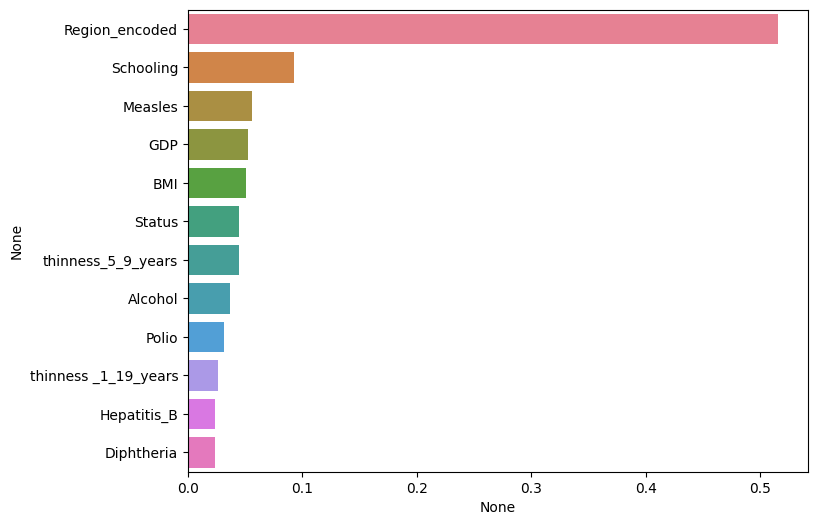

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x= feat_impt_ser,
    y = feat_impt_ser.index,
    hue = feat_impt_ser.index
)

plt.show()